In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import sys
from scipy.integrate import solve_ivp
from pathlib import Path

In [2]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from configuration.settings import *
from model.dynamic import PEMFC_dyn
from model.static import PEMFC_stat
from model.coefficients import *
from configuration.initialize import *

## In this file the massflow dynamic is compared.
### For the gas channel dynamic, following assumption is given:
The time constant of supply manifold is large, but reasonable value.
The inlet and outlet velocity of the static model are assumed empirically, using the dynamic value as the reference.

In [3]:
I_points = [10, 20, 30, 40, 50]

dyn_log_all = {}

for RHC in [0, 0.5]:
    for P_des in [1.3,1.4,1.5]:
        for T_des in [50,60,70]:
            if RHC == 0 and P_des != 1.3:
                continue # Skip the condition that not yet carried out on the experimental side
            else:
                pass

            states_dyn_log = []
            time_evolutions = []
            massflow_dyn_log = []

            for I_LOAD in I_points:
                # --------------- Dynamic Simulation  --------------- #
                operating_inputs["Phi_c_des"] = RHC 
                operating_inputs["Pa_des"] = P_des * 1e5
                operating_inputs["Pc_des"] = P_des * 1e5
                operating_inputs["Tfc"] = T_des + 273.15
                operating_inputs["current_density"] = lambda x: I_LOAD/parameters["Aact"]
                model = PEMFC_dyn(parameters,operating_inputs, init_x(operating_inputs, parameters))
                sol = solve_ivp(model.dxdt, (0, 90), init_x(operating_inputs, parameters), method='BDF', max_step=1e-1)
                model._recovery(sol)
                # --------------- Log states for dynamic simulation  --------------- #
                states = {} # Log the last state values for each variable => pseudo steady-state values 
                time_evo = {} # Log the time evolution of each variable => check for convergence to steady-state
                for key, var_name in enumerate(model.variables):
                    states[var_name] = model.variables[var_name][-1]
                    time_evo[var_name] = model.variables[var_name]
                for key, var_name in enumerate(model.elec_variables):
                    states[var_name] = model.elec_variables[var_name][-1]
                    time_evo[var_name] = model.elec_variables[var_name]
                massflow_dyn = model.calculate_flows(sol.t[-1], states)

                states_dyn_log.append(states)
                time_evolutions.append(time_evo)
                massflow_dyn_log.append(massflow_dyn)
                
            # --------------- Log states profile for both simulations  --------------- #
            states_profile_dyn = {}
            for key, value in enumerate(states_dyn_log[0].keys()):
                states_profile_dyn[value] = [states[value] for states in states_dyn_log]
            dyn_log_all["RHA"+str(0)+"/RHC" + str(RHC) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_profile_dyn, "time_evolution":time_evolutions, "massflow": massflow_dyn_log}

### Compare the inlet and outlet massflow
All unit are converted into $mol/(m^3\cdot s)$

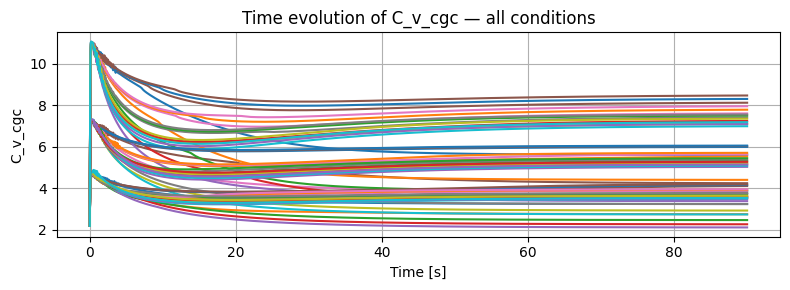

In [4]:
fig, ax = plt.subplots(figsize=(8, 3))

for cond_key, cond_data in dyn_log_all.items():
    for j, I in enumerate(I_points):
        te = cond_data["time_evolution"][j]
        ax.plot(te["t"], te["C_v_cgc"], label=f"{cond_key}, I={I}A")

ax.set_xlabel("Time [s]")
ax.set_ylabel("C_v_cgc")
ax.set_title("Time evolution of C_v_cgc — all conditions")
ax.grid(True)
fig.tight_layout()
plt.show()

In [5]:
stat_log_all = {}

for RHC in [0, 0.5]:
    for P_des in [1.3,1.4,1.5]:
        for T_des in [50,60,70]:
            if RHC == 0 and P_des != 1.3:
                continue # Skip the condition that not yet carried out on the experimental side
            else:
                pass
            states_stat = []
            for I_LOAD in I_points:
                # --------------- Steady-state Simulation  --------------- #
                Wout_c = 8 + I_LOAD * 0.25
                Win_c = 3 + I_LOAD * 0.3
                operating_inputs_stat = {'Tfc': T_des + 273.15, 'Phi_a_des': 0, 'Phi_c_des': RHC,
                                                             'Pa_des': P_des * 1e5, 'Pc_des': P_des * 1e5,
                                                             'Win_c': Win_c, 'Wout_c': Wout_c, 'Win_a': 4.8, 'Wout_a': 6.8}
                model = PEMFC_stat(parameters,operating_inputs_stat)
                sol = model.solve(I_LOAD/parameters['Aact'])
                # --------------- Log states for steady-state simulation  --------------- #
                states_stat.append(sol)
            # --------------- Log states for both simulations  --------------- #
            stat_log_all["RHA"+str(0)+"/RHC" + str(RHC) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_stat}

In [47]:
import re
import pandas as pd

raw_dir = project_root / "data" / "rawdata"
sim_keys = sorted(set(stat_log_all) | set(dyn_log_all))
p_to_tag = {1.3: 300, 1.4: 400, 1.5: 500}

# Parse simulation conditions
sim_cond = {}
for key in sim_keys:
    m = re.search(r"RHC([0-9.]+)_P([0-9.]+)_T([0-9]+)", key)
    if m:
        sim_cond[key] = {
            "rhc": float(m.group(1)),
            "p_tag": p_to_tag.get(float(m.group(2))),
            "t": int(m.group(3)),
        }

# Read REC sheets and summarize each sheet into one operating point
rec_points_by_temp = {}
for t in sorted({v["t"] for v in sim_cond.values()}):
    fpath = raw_dir / f"SYNTH_T{t}_N1.xlsx"
    if not fpath.exists():
        rec_points_by_temp[t] = []
        continue

    xls = pd.ExcelFile(fpath)
    rec_sheets = [s for s in xls.sheet_names if s.upper().startswith("REC_")]
    points = []

    for sname in rec_sheets:
        df = pd.read_excel(fpath, sheet_name=sname)
        num = df.apply(pd.to_numeric, errors="coerce")

        needed = [c for c in ["I_LOAD", "P_AIR", "HR_AIR_FC"] if c in num.columns]
        if len(needed) < 3:
            continue

        i_mean = float(num["I_LOAD"].mean())
        p_mean = float(num["P_AIR"].mean())
        hr_mean = float(num["HR_AIR_FC"].mean())

        p_tag = min([300, 400, 500], key=lambda p: abs(p_mean - p))
        rhc_tag = min([0.0, 0.5], key=lambda r: abs(hr_mean - 100 * r))

        col_means = {col: float(num[col].mean()) for col in num.columns if num[col].notna().any()}

        points.append({
            "sheet": sname,
            "i_mean": i_mean,
            "p_tag": p_tag,
            "rhc_tag": rhc_tag,
            "col_means": col_means,
        })

    rec_points_by_temp[t] = points

# Build aux_data_exp in simulation-like format: {'states': {column_name: [value per I_points]}}
aux_data_exp = {}
for key, cond in sim_cond.items():
    pts = [p for p in rec_points_by_temp.get(cond["t"], []) if p["p_tag"] == cond["p_tag"] and p["rhc_tag"] == cond["rhc"]]

    if not pts:
        aux_data_exp[key] = {"states": {}}
        continue

    state_names = sorted(set().union(*(p["col_means"].keys() for p in pts)))
    states = {name: [] for name in state_names}

    for I in I_points:
        near = [p for p in pts if abs(p["i_mean"] - I) <= 2.0]
        if not near:
            # fallback: closest sheet to this current
            near = [min(pts, key=lambda p: abs(p["i_mean"] - I))]

        for name in state_names:
            vals = [p["col_means"].get(name) for p in near]
            vals = [v for v in vals if v is not None and pd.notna(v)]
            states[name].append(float(sum(vals) / len(vals)) if vals else float("nan"))

    aux_data_exp[key] = {"states": states}

loaded = sum(bool(v.get("states")) for v in aux_data_exp.values())
print(f"aux_data_exp: {len(aux_data_exp)} keys | with_states={loaded}")
print("sample states:", list(next((v["states"].keys() for v in aux_data_exp.values() if v["states"]), []))[:10])

aux_data_exp: 12 keys | with_states=12
sample states: ['AIR_FLOW', 'COND_H2O', 'DEB_AIR*', 'DEB_H2*', 'DEB_H2O', 'DEVAIR* ', 'DEVH2*', 'D_H2O*', 'Date', 'EV3V_600*']


In [ ]:
# Print only column names (using first sheet as representative)
raw_dir = project_root / "data" / "rawdata"
files = sorted(raw_dir.glob("SYNTH_T*_N1.xlsx"))

for f in files:
    xls = pd.ExcelFile(f)
    first_sheet = xls.sheet_names[0]
    cols = list(pd.read_excel(f, sheet_name=first_sheet, nrows=0).columns)
    print(f"\n{f.name}:")
    print(cols)


T=50, sample sheets=['REC_06022026_091529', 'REC_06022026_093700', 'REC_06022026_095442']
REC_06022026_091529 {'I_LOAD': (10.012945182724252, 0.0036372977824071966), 'P_AIR': (303.3190332225914, 0.3265904927825577), 'HR_AIR_FC': (50.966310631229234, 0.21368588027184757), 'DEB_H2O': (3.067641196013289, 0.0015535362157011027)}
REC_06022026_093700 {'I_LOAD': (10.014536912751677, 0.003601630797633182), 'P_AIR': (398.93692617449665, 0.3567904376372411), 'HR_AIR_FC': (47.15919463087249, 0.20403341884293746), 'DEB_H2O': (3.0718255033557043, 0.001064201558113526)}
REC_06022026_095442 {'I_LOAD': (10.014512479201331, 0.003679709319586347), 'P_AIR': (500.1655840266223, 9.042145183528687), 'HR_AIR_FC': (46.51860898502496, 0.35070757788476936), 'DEB_H2O': (3.042575707154742, 0.0011681932805685529)}

T=60, sample sheets=['REC_27022026_084227', 'REC_27022026_085858', 'REC_27022026_091634']
REC_27022026_084227 {'I_LOAD': (9.898696458684656, 0.0035306004397167748), 'P_AIR': (299.2383288364249, 0.70182

### Cathode Gas Channel

#### Static Model (Algebraic)

In steady-state operation, the gas channel concentrations are computed algebraically from mass balance, assuming instantaneous equilibrium:

**Vapor Concentration ($C_{v,cgc}$) - Static:**
$$C_{v,cgc} = \frac{J_w L_{gc}/H_{gc} + C_{v,in} W_{in}}{W_{out}}$$

Where:
- $J_w$ = net vapor flow from CL (positive direction: CL -> GC)
- $C_{v,in}$ = inlet vapor concentration
- $W_{in}$, $W_{out}$ = inlet/outlet mass flow rates
- $P_c$ = cathode pressure

In the figure below, the massflow of static model $J_{v,c}(mol/(m^3\cdot s))$ is presented:
$$J_{v,c} = W_{in,c} * \Phi_{a, des} * C_{v,sat}(T_{fc})/L_{gc}$$

#### Dynamic Model (PDE)

The dynamic model tracks time-evolving concentrations accounting for inlet/outlet flows and GDL exchange:

**Vapor Concentration ($C_{v,cgc}$) - Dynamic ODE:**
$$\frac{dC_{v,cgc}}{dt} = \frac{J_{v,c,in} - J_{v,c,out}}{L_{gc}} + \frac{J_{v,cgdl \to cgc}}{H_{gc}}$$

Where:
- $J_{v,c,in}$, $J_{v,c,out}$ = inlet/outlet vapor molar fluxes [mol/(m²·s)]
- $J_{v,cgdl \to cgc}$, $J_{O_2,cgdl \to cgc}$ = molar fluxes from GDL to CGC [mol/(m²·s)]
- $L_{gc}$ = gas channel length [m]
- $H_{gc}$ = gas channel height [m]

**Key Difference:** The dynamic model accounts for transient accumulation of vapor and oxygen in the channel, making it sensitive to control input changes (humidity, inlet flow), while the static model assumes quasi-steady behavior.

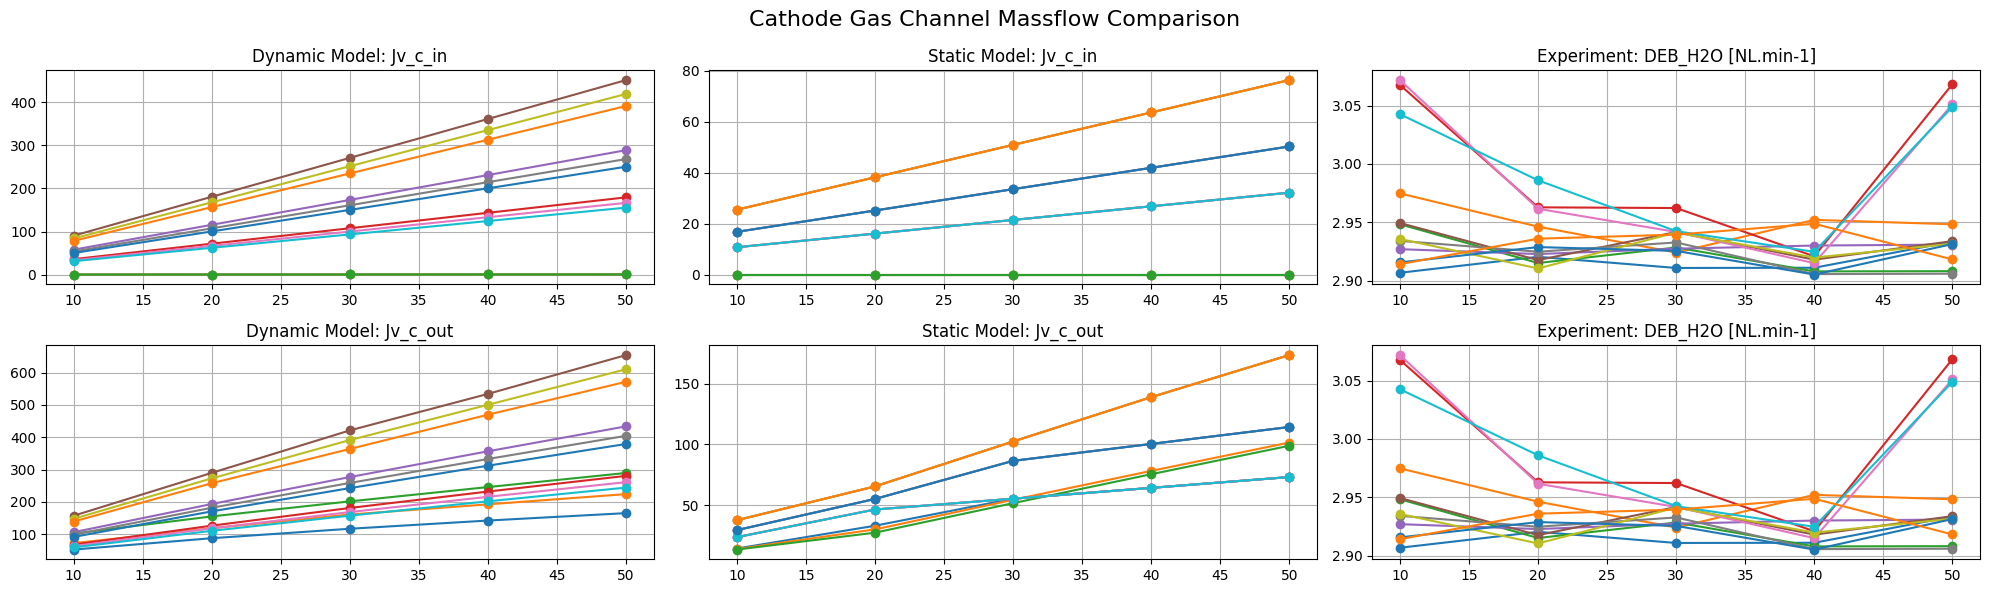

In [48]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 6))
fig.suptitle("Cathode Gas Channel Massflow Comparison", fontsize=16)

for key in dyn_log_all.keys():
    states_dyn = dyn_log_all[key]["states"]
    states_stat = stat_log_all[key]["states"]
    massflow_dyn = dyn_log_all[key]["massflow"]

    # Dynamic vs static model results
    axes[0,0].plot(I_points, [massflow["Jv_c_in"] / parameters["Lgc"] for massflow in massflow_dyn], label=key, marker='o')
    axes[0,1].plot(I_points, [states["Jv_c_in"] for states in states_stat], label=key, marker='o')
    axes[1,0].plot(I_points, [massflow["Jv_c_out"] / parameters["Lgc"] for massflow in massflow_dyn], label=key, marker='o')
    axes[1,1].plot(I_points, [states["Jv_c_out"] for states in states_stat], label=key, marker='o')

    # Experimental result stored as states by current point
    exp_states = aux_data_exp.get(key, {}).get("states", {})
    if "DEB_H2O" in exp_states:
        axes[0,2].plot(I_points, exp_states["DEB_H2O"], label=key, marker='o', linestyle='-')
        axes[1,2].plot(I_points, exp_states["DEB_H2O"], label=key, marker='o', linestyle='-')

axes[0,0].set_title("Dynamic Model: Jv_c_in")
axes[0,1].set_title("Static Model: Jv_c_in")
axes[0,2].set_title("Experiment: DEB_H2O [NL.min-1]")
axes[1,0].set_title("Dynamic Model: Jv_c_out")
axes[1,1].set_title("Static Model: Jv_c_out")
axes[1,2].set_title("Experiment: DEB_H2O [NL.min-1]")

for ax in axes.flat:
    ax.grid(True)

plt.tight_layout()
plt.show()

### Anode Gas Channel Vapor Concentration Result (Static vs Dynamic)

This section focuses only on anode gas channel vapor concentration, $C_{v,agc}$.

Dynamic model result:
- $C_{v,agc}$ changes with time before reaching a stable value for each operating point.
- At higher load, the final $C_{v,agc}$ level is generally higher because water generation is stronger.
- Changes in operating condition (pressure/humidity setpoint) affect both the transient response speed and the final concentration level.

Static model result:
- The model gives one steady-state value of $C_{v,agc}$ per operating point (no transient trajectory).
- These values represent equilibrium vapor concentration in the anode gas channel.

Comparison insight:
- Static results correspond to the final equilibrium level.
- Dynamic results add the transient path toward that level, which is important for startup and load-change analysis.

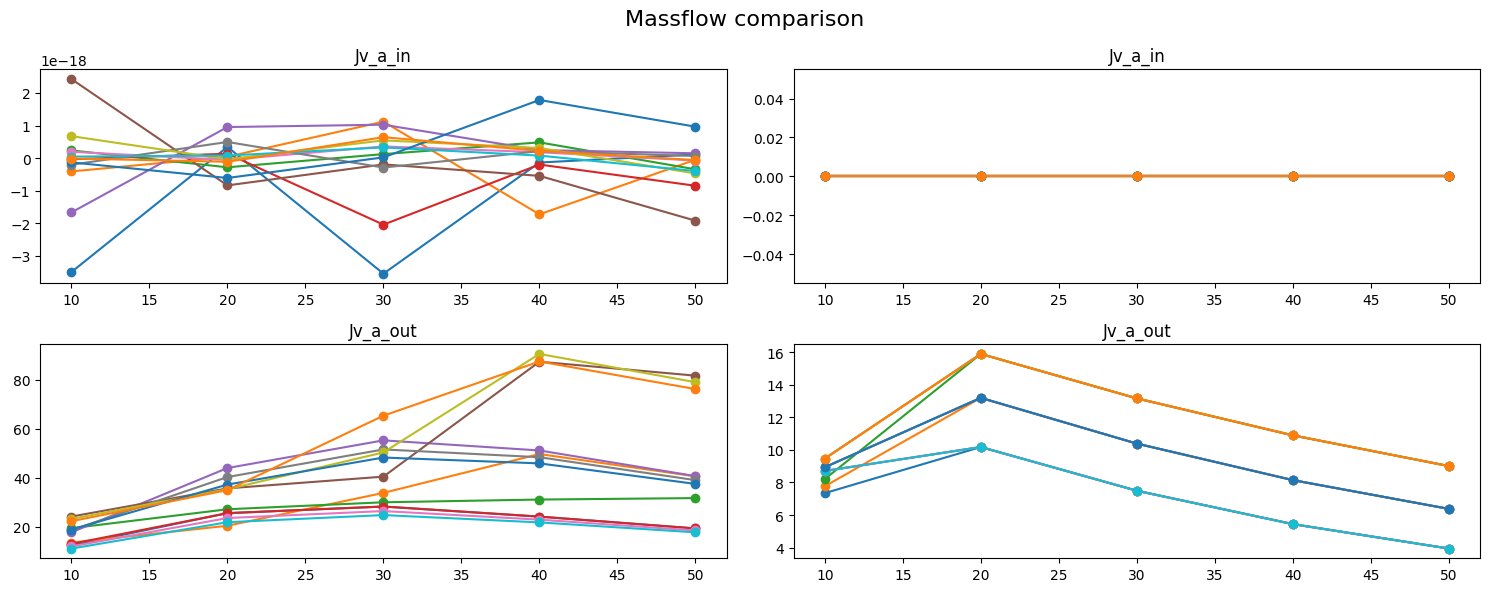

In [18]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 6))
fig.suptitle("Massflow comparison", fontsize=16)

for key in dyn_log_all.keys():
    states_dyn = dyn_log_all[key]["states"]
    states_stat = stat_log_all[key]["states"]
    massflow_dyn = dyn_log_all[key]["massflow"]

    axes[0,0].plot(I_points, [massflow["Jv_a_in"] for massflow in massflow_dyn], label=key, marker='o')
    axes[0,1].plot(I_points, [states["Jv_a_in"] for states in states_stat], label=key, marker='o')
    axes[1,0].plot(I_points, [massflow["Jv_a_out"] for massflow in massflow_dyn], label=key, marker='o')
    axes[1,1].plot(I_points, [states["Jv_a_out"] for states in states_stat], label=key, marker='o')

axes[0,0].set_title("Jv_a_in")
axes[0,1].set_title("Jv_a_in")
axes[1,0].set_title("Jv_a_out")
axes[1,1].set_title("Jv_a_out")

plt.tight_layout()
plt.show()

### GDL Massflow Comparison (Anode vs Cathode)

The equations below are the GDL state equations used in this project (from `model/dynamic.py`, `model/static.py`, and summarized in `README.md`).

#### Dynamic model (state equations)
For each GDL node $i$:

$$\frac{dC_{v,gdl,i}}{dt}=\frac{1}{\varepsilon_{gdl}(1-s_i)}\left(\frac{J_{v,i-1}-J_{v,i}}{\Delta x_{gdl}}+S_{v,i}\right)$$

$$\frac{dC_{v,gdl,i}}{dt}=\frac{1}{\varepsilon_{gdl}(1-s_i)}\left(\frac{J_{v,i-1}-J_{v,i}}{\Delta x_{gdl}}\right)$$

$$\frac{ds_{gdl,i}}{dt}=\frac{1}{\rho_{H_2O}\,\varepsilon_{gdl}}\left(\frac{J_{l,i-1}-J_{l,i}}{\Delta x_{gdl}}+M_{H_2O}S_{l,i}\right)$$

In code, the plotted dynamic GDL liquid fluxes are:
- Anode side: `Jl_agdl_acl`
- Cathode side: `Jl_ccl_cgdl`

#### Static model (algebraic equations)
No time derivative is solved in the static model. The GDL is computed from algebraic profiles:

$$C_{v,gdl}(x)=C_{v,inter}+\frac{x}{D_{eff}}J_w$$

$$C_{v,gdl}(x)=C_{v,inter}+\frac{x}{D_{eff}(s)}J_{v}$$

Saturation is obtained from Leverett-type inversion in `gdl_profile(...)` (via `self._solve_sat(...)`), with front tracking by:

$$x_{front}=\frac{(C_{v,sat}-C_{v,inter})D_{eff}}{J_w}$$

In the static results used in the plot:
- Anode-side water flux proxy: `Jw_an`
- Cathode-side water flux proxy: `Jw_ca`

So this figure compares dynamic GDL transport fluxes against their static algebraic counterparts for both anode and cathode.

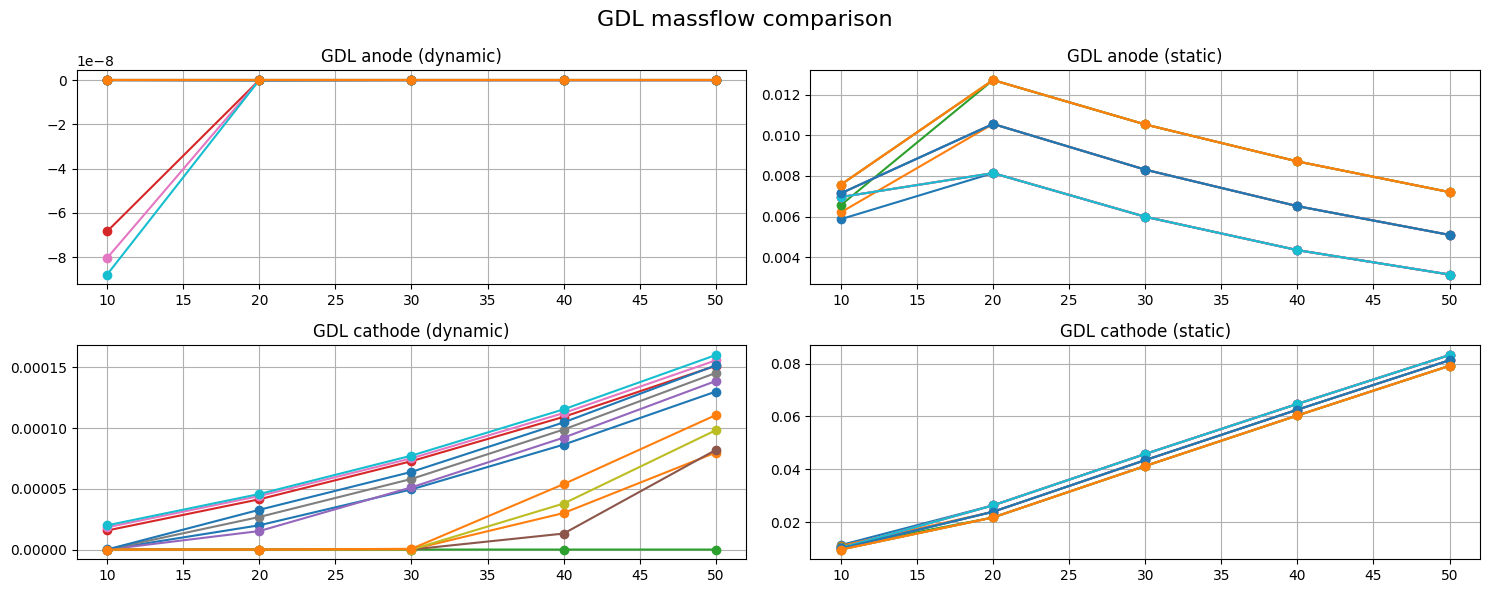

In [21]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 6))
fig.suptitle("GDL massflow comparison", fontsize=16)

for key in dyn_log_all.keys():
    states_stat = stat_log_all[key]["states"]
    massflow_dyn = dyn_log_all[key]["massflow"]

    # Anode GDL
    axes[0,0].plot(I_points, [massflow["Jl_agdl_acl"] for massflow in massflow_dyn], label=key, marker='o')
    axes[0,1].plot(I_points, [states["Jw_an"] for states in states_stat], label=key, marker='o')

    # Cathode GDL
    axes[1,0].plot(I_points, [massflow["Jl_ccl_cgdl"] for massflow in massflow_dyn], label=key, marker='o')
    axes[1,1].plot(I_points, [states["Jw_ca"] for states in states_stat], label=key, marker='o')

axes[0,0].set_title("GDL anode (dynamic)")
axes[0,1].set_title("GDL anode (static)")
axes[1,0].set_title("GDL cathode (dynamic)")
axes[1,1].set_title("GDL cathode (static)")

for ax in axes.flat:
    ax.grid(True)

plt.tight_layout()
plt.show()

### Membrane Massflow Comparison (Anode vs Cathode)

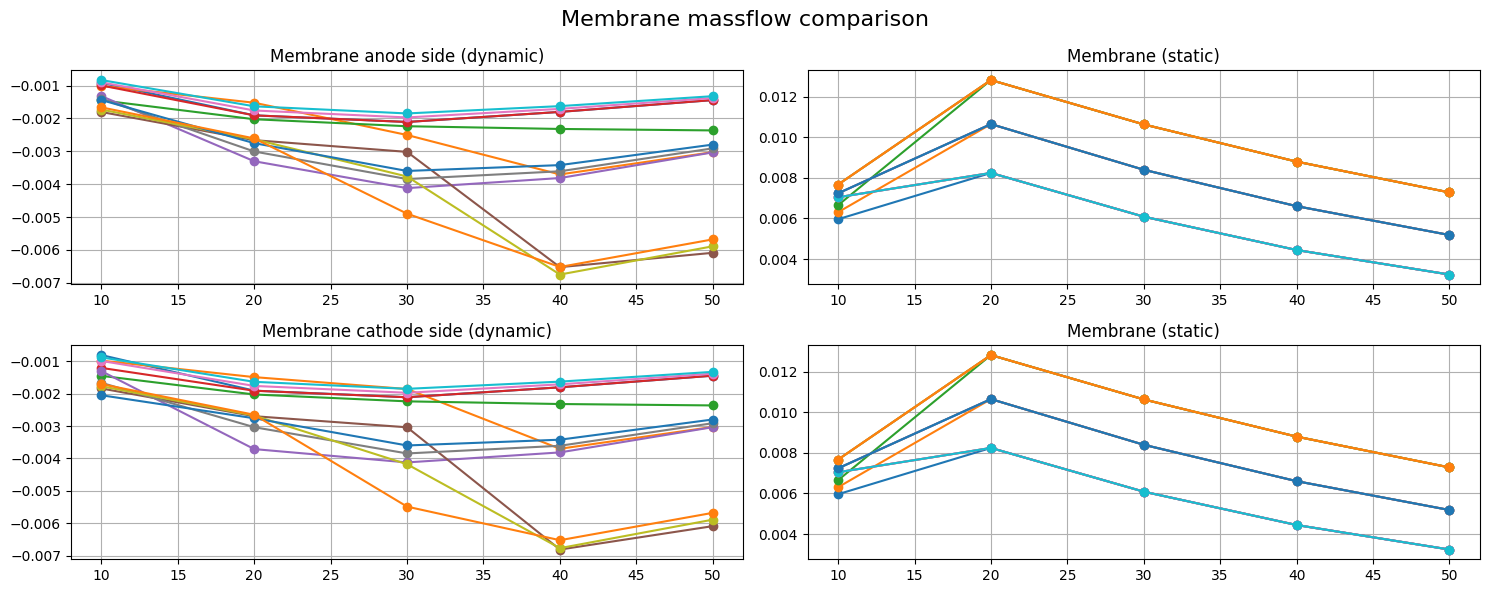

In [22]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 6))
fig.suptitle("Membrane massflow comparison", fontsize=16)

for key in dyn_log_all.keys():
    states_stat = stat_log_all[key]["states"]
    massflow_dyn = dyn_log_all[key]["massflow"]

    # Membrane transport mapped to anode side
    axes[0,0].plot(I_points, [massflow["J_lambda_mem_acl"] for massflow in massflow_dyn], label=key, marker='o')
    axes[0,1].plot(I_points, [states["Jmem"] for states in states_stat], label=key, marker='o')

    # Membrane transport mapped to cathode side
    axes[1,0].plot(I_points, [massflow["J_lambda_mem_ccl"] for massflow in massflow_dyn], label=key, marker='o')
    axes[1,1].plot(I_points, [states["Jmem"] for states in states_stat], label=key, marker='o')

axes[0,0].set_title("Membrane anode side (dynamic)")
axes[0,1].set_title("Membrane (static)")
axes[1,0].set_title("Membrane cathode side (dynamic)")
axes[1,1].set_title("Membrane (static)")

for ax in axes.flat:
    ax.grid(True)

plt.tight_layout()
plt.show()